# Laboratorio 1 — Regresión Lineal Multivariable
## Dataset: Contaminación del Aire 2000-2021

Aplicado al conjunto de datos de calidad del aire de EE.UU. (2000-2021).
El dataset cuenta con **24 propiedades** (n ≥ 20) y más de **600,000 registros** (m ≥ 20,000).

Se trabajan **3 modelos** en este cuadernillo:
1. Regresión lineal multivariable (descenso de gradiente)
2. Regresión polinómica (descenso de gradiente)
3. Ecuación normal

In [5]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot

## 1. Carga y exploración del dataset

El archivo `contaminacion_2000_2021.csv` contiene mediciones diarias de ozono (O3), monóxido de carbono (CO), dióxido de azufre (SO2) y dióxido de nitrógeno (NO2) en ciudades de EE.UU.

- **Variable objetivo (y):** O3 ICA (Índice de Calidad del Aire del Ozono)
- **Variables de entrada (X):** año, mes, día, O3 promedio, O3 máximo, O3 hora máxima, CO promedio, CO máximo, CO hora máxima, CO ICA, SO2 promedio, SO2 máximo, SO2 hora máxima, SO2 ICA, NO2 promedio, NO2 máximo, NO2 hora máxima, NO2 ICA **(n = 18 variables numéricas)**

In [6]:
# Leer datos del dataset de contaminación del aire
# Columnas numéricas seleccionadas (índice 0-based con separador ";"):
#   1=Anio, 2=Mes, 3=Dia
#   8=O3 Promedio, 9=O3 Valor Maximo, 10=O3 Hora Maxima
#   12=CO Promedio, 13=CO Valor Maximo, 14=CO Hora Maxima, 15=CO ICA
#   16=SO2 Promedio, 17=SO2 Valor Maximo, 18=SO2 Hora Maxima, 19=SO2 ICA
#   20=NO2 Promedio, 21=NO2 Valor Maximo, 22=NO2 Hora Maxima, 23=NO2 ICA
#   11=O3 ICA  <- variable objetivo (última posición en usecols)
data = np.genfromtxt(
    'contaminacion_2000_2021.csv',
    delimiter=';',
    skip_header=1,
    usecols=(1, 2, 3, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 11),
    encoding='utf-8',
    invalid_raise=False
)

# Eliminar filas con NaN (valores que no se pudieron convertir a número)
data = data[~np.isnan(data).any(axis=1)]

# Separar en X (primeras 18 columnas) e y (última columna = O3 ICA)
X = data[:, :18]
y = data[:, 18]
m = y.size

print(f'Número de ejemplos de entrenamiento (m): {m}')
print(f'Número de propiedades (n): {X.shape[1]}')
print()
print('Primeras 5 filas de X (Anio, Mes, Dia, O3_Prom, O3_Max, ...):')
print(X[:5])

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_4796\66915089.py:9: ConversionWarning: Some errors were detected !
    Line #7056 (got 5 columns instead of 19)
    Line #7057 (got 5 columns instead of 19)
    Line #7058 (got 5 columns instead of 19)
    Line #7059 (got 5 columns instead of 19)
    Line #7060 (got 5 columns instead of 19)
    Line #7061 (got 5 columns instead of 19)
    Line #7062 (got 5 columns instead of 19)
    Line #7063 (got 5 columns instead of 19)
    Line #7064 (got 5 columns instead of 19)
    Line #7065 (got 5 columns instead of 19)
    Line #7066 (got 5 columns instead of 19)
    Line #7067 (got 5 columns instead of 19)
    Line #7068 (got 5 columns instead of 19)
    Line #7069 (got 5 columns instead of 19)
    Line #7070 (got 5 columns instead of 19)
    Line #7071 (got 5 columns instead of 19)
    Line #7072 (got 5 columns instead of 19)
    Line #7073 (got 5 columns instead of 19)
    Line #7074 (got 5 columns instead of 19)
    Line #7075 (got 5 columns ins

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_4796\66915089.py:9: ConversionWarning: Some errors were detected !
    Line #7056 (got 5 columns instead of 19)
    Line #7057 (got 5 columns instead of 19)
    Line #7058 (got 5 columns instead of 19)
    Line #7059 (got 5 columns instead of 19)
    Line #7060 (got 5 columns instead of 19)
    Line #7061 (got 5 columns instead of 19)
    Line #7062 (got 5 columns instead of 19)
    Line #7063 (got 5 columns instead of 19)
    Line #7064 (got 5 columns instead of 19)
    Line #7065 (got 5 columns instead of 19)
    Line #7066 (got 5 columns instead of 19)
    Line #7067 (got 5 columns instead of 19)
    Line #7068 (got 5 columns instead of 19)
    Line #7069 (got 5 columns instead of 19)
    Line #7070 (got 5 columns instead of 19)
    Line #7071 (got 5 columns instead of 19)
    Line #7072 (got 5 columns instead of 19)
    Line #7073 (got 5 columns instead of 19)
    Line #7074 (got 5 columns instead of 19)
    Line #7075 (got 5 columns ins

Número de ejemplos de entrenamiento (m): 116363
Número de propiedades (n): 18

Primeras 5 filas de X (Anio, Mes, Dia, O3_Prom, O3_Max, ...):
[[2.00000e+03 1.00000e+00 3.00000e+00 9.35300e-03 1.60000e-02 9.00000e+00
  1.76250e+01 2.50000e+00 8.00000e+00 2.80000e+01 5.25000e+00 1.10000e+01
  1.90000e+01 1.60000e+01 3.81250e+01 5.10000e+01 8.00000e+00 4.80000e+01]
 [2.00000e+03 1.00000e+00 1.70000e+01 9.35300e-03 1.50000e-02 8.00000e+00
  1.98750e+01 3.90000e+00 2.30000e+01 4.40000e+01 8.50000e+00 1.90000e+01
  2.30000e+01 2.70000e+01 5.92500e+01 1.01000e+02 2.30000e+01 1.01000e+02]
 [2.00000e+03 3.00000e+00 1.70000e+01 2.91180e-02 5.10000e-02 1.20000e+01
  9.91667e-01 1.80000e+00 2.00000e+00 2.00000e+01 8.69570e-02 4.00000e-01
  2.20000e+01 0.00000e+00 3.38750e+01 5.80000e+01 1.00000e+01 5.50000e+01]
 [2.00000e+03 3.00000e+00 1.80000e+01 3.15880e-02 5.00000e-02 1.10000e+01
  6.95833e-01 1.10000e+00 8.00000e+00 1.30000e+01 3.04348e-01 9.00000e-01
  2.10000e+01 0.00000e+00 3.11250e+01 5.80

## 2. Normalización de características

### Fórmula: $X_{norm} = \frac{X - \mu}{\sigma}$

Donde $\mu$ es la media y $\sigma$ la desviación estándar de cada característica. Esto hace que todas las variables tengan escala similar para que el descenso de gradiente converja más rápido.

In [7]:
def normalizarCaracteristicas(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1  # evitar división por cero
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [8]:
# llama normalizarCaracteristicas con los datos cargados
X_norm, mu, sigma = normalizarCaracteristicas(X)

print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm[:3])

Media calculada: [2.01279381e+03 6.51312702e+00 1.57952958e+01 2.96812564e-02
 3.88283905e-02 1.08423210e+01 2.75570538e-01 3.43864459e-01
 5.01683525e+00 3.82089668e+00 2.30175541e+00 2.18997018e+00
 8.26898585e+00 2.65098012e+00 4.45373303e+01 1.76441945e+01
 1.11517149e+01 1.64377938e+01]
Desviación estandar calculada: [5.69213199e+00 3.18335940e+00 8.79921638e+00 1.14402905e-02
 1.36881407e-02 3.39609595e+00 8.85148961e-01 2.77925010e-01
 7.46967321e+00 3.26131634e+00 2.26791999e+01 5.57055151e+00
 7.05329945e+00 7.43182060e+00 1.20764620e+02 1.38448789e+01
 8.01467421e+00 1.30629049e+01]
[[-2.24763042 -1.73185818 -1.45414037 -1.77690037 -1.66774955 -0.54248203
  19.60057598  7.75797595  0.39937018  7.41390924  0.12999773  1.58153637
   1.52141763  1.79619781 -0.05309776  2.40925224 -0.39324304  2.41617055]
 [-2.24763042 -1.73185818  0.1369104  -1.77690037 -1.7408055  -0.83693778
  22.14252101 12.79530599  2.40749016 12.31990374  0.27330085  3.01765988
   2.08852811  3.27631965  0.

## 3. Visualización de los datos

Se grafican las relaciones entre las características (normalizadas) y la variable objetivo para comprender el comportamiento del dataset.

In [9]:
def graficarDatos(x, y, xlabel, ylabel):
  fig = pyplot.figure()
  pyplot.plot(x, y, 'ro', markersize=2, alpha=0.3)
  pyplot.xlabel(xlabel)
  pyplot.ylabel(ylabel)

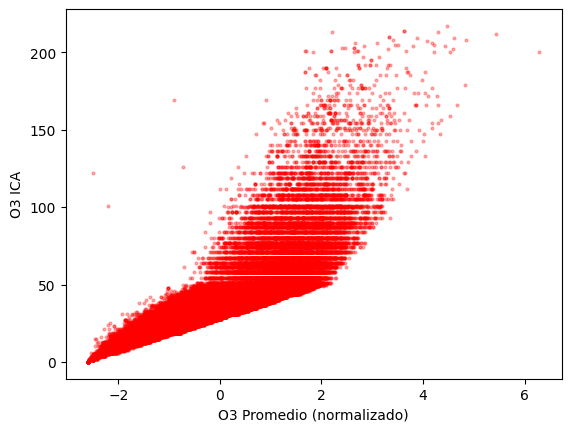

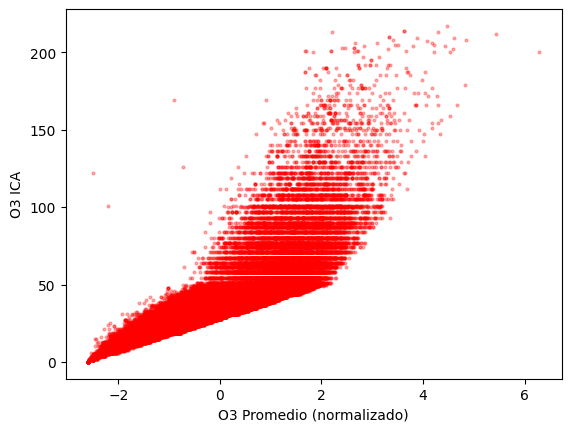

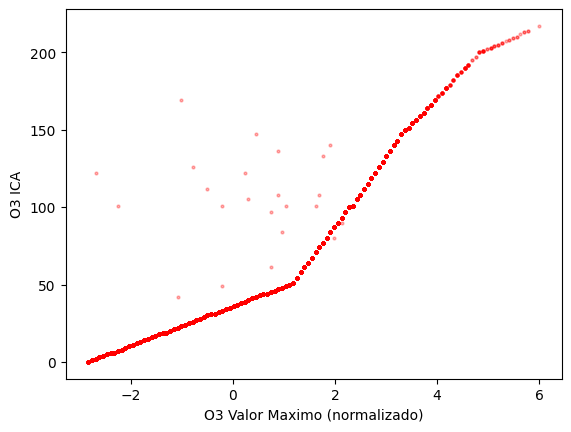

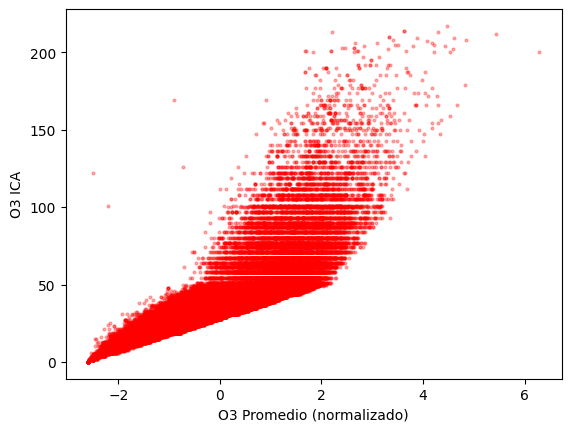

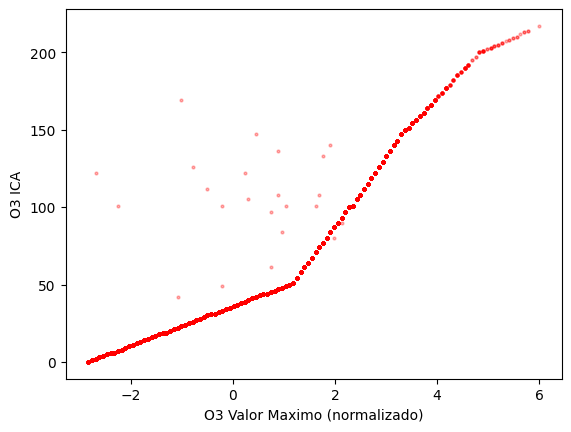

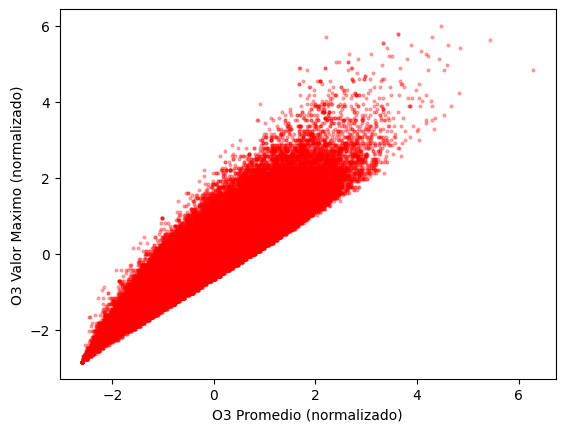

In [10]:
xlabel1 = "O3 Promedio (normalizado)"
xlabel2 = "O3 Valor Maximo (normalizado)"
ylabel1 = "O3 ICA"

graficarDatos(X_norm[:, 3], y, xlabel1, ylabel1)
graficarDatos(X_norm[:, 4], y, xlabel2, ylabel1)
graficarDatos(X_norm[:, 3], X_norm[:, 4], xlabel1, xlabel2)

## 4. División entrenamiento / validación

Se separa el dataset: 80% para entrenamiento y 20% para validación, para evaluar la efectividad del modelo con datos no vistos.

In [11]:
# Mezclar los índices aleatoriamente
np.random.seed(42)
indices = np.random.permutation(m)

# 80% entrenamiento, 20% validación
m_val = int(m * 0.2)
idx_val = indices[:m_val]
idx_train = indices[m_val:]

X_norm_train = X_norm[idx_train]
y_train = y[idx_train]

X_norm_val = X_norm[idx_val]
y_val = y[idx_val]

# Agregar columna de unos (término de intersección theta_0) a cada conjunto
X_train = np.concatenate([np.ones((len(idx_train), 1)), X_norm_train], axis=1)
X_val_b = np.concatenate([np.ones((len(idx_val), 1)), X_norm_val], axis=1)

print(f'Ejemplos de entrenamiento: {X_train.shape[0]}')
print(f'Ejemplos de validación:    {X_val_b.shape[0]}')

Ejemplos de entrenamiento: 93091
Ejemplos de validación:    23272


## 5. Función de Costo $J(\theta)$

Mide qué tan lejos están las predicciones de los valores reales.

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$

Donde $h_\theta(x) = X \cdot \theta$ son las predicciones y $y$ los valores reales.

In [12]:
def calcularCosto(X, y, theta):
  m = y.size
  J = 0
  J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
  return J

In [13]:
# Probar la función de costo con theta inicial en cero
theta = np.zeros(X_train.shape[1])
JJ = calcularCosto(X_train, y_train, theta)
print(f"con theta: {theta[:4]} ... se obtiene un costo de: {JJ}")

con theta: [0. 0. 0. 0.] ... se obtiene un costo de: 921.0221396268167


## 6. Modelo 1 — Regresión Lineal Multivariable (Descenso de Gradiente)

Algoritmo iterativo que ajusta $\theta$ para minimizar $J(\theta)$.

$$\theta_j := \theta_j - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) \cdot x_j^{(i)}$$

En forma vectorizada: $\theta := \theta - \frac{\alpha}{m} \cdot X^T (X\theta - y)$

In [14]:
def calcularDescensoGradiente(X, y, theta, alpha, numero_iteraciones):
  m = y.shape[0]
  theta = theta.copy()
  J_historico = []

  for i in range(numero_iteraciones):
    theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
    J_historico.append(calcularCosto(X, y, theta))

  return theta, J_historico

los valores de theta calculados son: [ 3.82874625e+01  7.88722350e-02  9.38976389e-01 -2.62546249e-02
  1.25148014e+00  1.67650485e+01  1.11796515e-01 -2.56183758e-02
 -4.81515107e-03  7.73417209e-02  3.27727685e-01  3.75007927e-02
 -3.92703061e-02  9.76322273e-02  4.77625319e-01 -3.05228208e-02
  5.16220385e-01 -4.39714109e-02  5.69158274e-01]
con un costo de entrenamiento: 24.77521784026062
costo en validación: 24.926377722153436


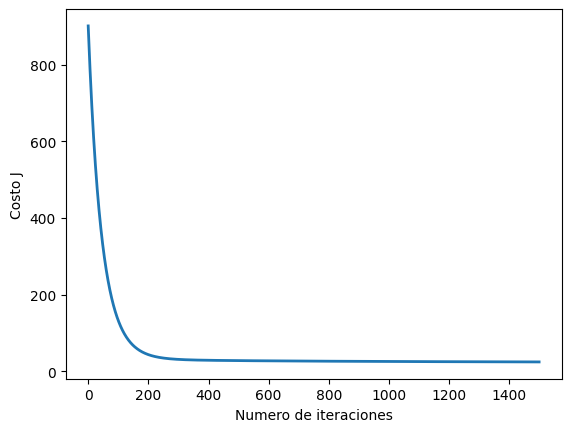

In [15]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.01
num_ite = 1500

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X_train.shape[1])
theta, J_historico = calcularDescensoGradiente(X_train, y_train, theta, alpha, num_ite)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_historico)), J_historico, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print(f"los valores de theta calculados son: {theta}")
print(f"con un costo de entrenamiento: {J_historico[-1]}")

# Costo en validación
J_val = calcularCosto(X_val_b, y_val, theta)
print(f"costo en validación: {J_val}")

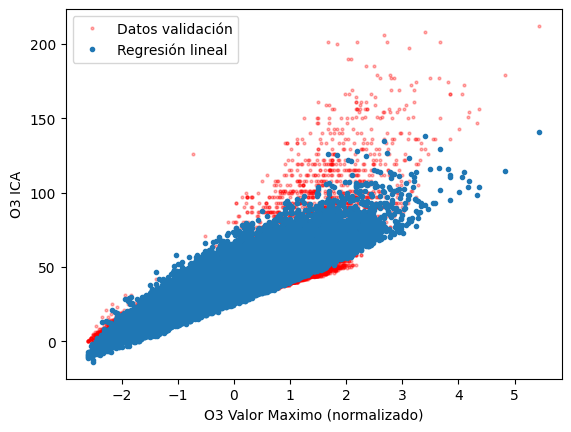

In [16]:
# Graficar datos de validación con línea de predicción
graficarDatos(X_val_b[:, 4], y_val, "O3 Valor Maximo (normalizado)", "O3 ICA")

pyplot.plot(X_val_b[:, 4], np.dot(X_val_b, theta), '.')

pyplot.legend(['Datos validación', 'Regresión lineal'])

In [17]:
# 120 predicciones del modelo lineal multivariable (>= 100 requeridas)
print('{:>10s}{:>15s}{:>15s}'.format('Ejemplo', 'Real (O3 ICA)', 'Prediccion'))
print('-' * 40)
for i in range(120):
    x_pred = X_val_b[i]
    y_pred = np.dot(x_pred, theta)
    print('{:>10d}{:>15.2f}{:>15.2f}'.format(i + 1, y_val[i], y_pred))

   Ejemplo  Real (O3 ICA)     Prediccion
----------------------------------------
         1          35.00          37.32
         2          40.00          43.00
         3          42.00          45.43
         4          51.00          58.85
         5          40.00          43.00
         6          39.00          41.05
         7          28.00          27.43
         8          30.00          29.78
         9          35.00          36.07
        10          13.00           5.43
        11          28.00          34.73
        12          34.00          36.25
        13          35.00          39.62
        14          18.00          10.70
        15          48.00          55.99
        16          27.00          24.51
        17          30.00          29.92
        18          40.00          43.24
        19          48.00          56.09
        20          50.00          56.27
        21          42.00          46.19
        22          58.00          60.66
        23      

## 7. Modelo 2 — Regresión Polinómica (grado 2)

Se extiende el modelo agregando los cuadrados de las primeras 3 características (Año², Mes², Día²) para capturar relaciones no lineales. Se reutilizan las mismas funciones `calcularCosto` y `calcularDescensoGradiente`.

El proceso es:
1. Agregar columnas $x_1^2, x_2^2, x_3^2$ a la matriz $X$
2. Normalizar el conjunto ampliado
3. Entrenar con descenso de gradiente

In [18]:
# Recargar datos originales para la sección polinómica
data_pol = np.genfromtxt(
    'contaminacion_2000_2021.csv',
    delimiter=';',
    skip_header=1,
    usecols=(1, 2, 3, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 11),
    encoding='utf-8',
    invalid_raise=False
)
data_pol = data_pol[~np.isnan(data_pol).any(axis=1)]

X_pol = data_pol[:, :18]
y_pol = data_pol[:, 18]
m_pol = y_pol.size

# Agregar columnas polinómicas: Anio^2, Mes^2, Dia^2 (índices 0,1,2)
X_pol = np.concatenate([X_pol, X_pol[:, :3] * X_pol[:, :3]], axis=1)

print(f'Dimensiones X con términos polinómicos: {X_pol.shape}')
print(X_pol[:3])

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_4796\25056474.py:2: ConversionWarning: Some errors were detected !
    Line #7056 (got 5 columns instead of 19)
    Line #7057 (got 5 columns instead of 19)
    Line #7058 (got 5 columns instead of 19)
    Line #7059 (got 5 columns instead of 19)
    Line #7060 (got 5 columns instead of 19)
    Line #7061 (got 5 columns instead of 19)
    Line #7062 (got 5 columns instead of 19)
    Line #7063 (got 5 columns instead of 19)
    Line #7064 (got 5 columns instead of 19)
    Line #7065 (got 5 columns instead of 19)
    Line #7066 (got 5 columns instead of 19)
    Line #7067 (got 5 columns instead of 19)
    Line #7068 (got 5 columns instead of 19)
    Line #7069 (got 5 columns instead of 19)
    Line #7070 (got 5 columns instead of 19)
    Line #7071 (got 5 columns instead of 19)
    Line #7072 (got 5 columns instead of 19)
    Line #7073 (got 5 columns instead of 19)
    Line #7074 (got 5 columns instead of 19)
    Line #7075 (got 5 columns ins

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_4796\25056474.py:2: ConversionWarning: Some errors were detected !
    Line #7056 (got 5 columns instead of 19)
    Line #7057 (got 5 columns instead of 19)
    Line #7058 (got 5 columns instead of 19)
    Line #7059 (got 5 columns instead of 19)
    Line #7060 (got 5 columns instead of 19)
    Line #7061 (got 5 columns instead of 19)
    Line #7062 (got 5 columns instead of 19)
    Line #7063 (got 5 columns instead of 19)
    Line #7064 (got 5 columns instead of 19)
    Line #7065 (got 5 columns instead of 19)
    Line #7066 (got 5 columns instead of 19)
    Line #7067 (got 5 columns instead of 19)
    Line #7068 (got 5 columns instead of 19)
    Line #7069 (got 5 columns instead of 19)
    Line #7070 (got 5 columns instead of 19)
    Line #7071 (got 5 columns instead of 19)
    Line #7072 (got 5 columns instead of 19)
    Line #7073 (got 5 columns instead of 19)
    Line #7074 (got 5 columns instead of 19)
    Line #7075 (got 5 columns ins

Dimensiones X con términos polinómicos: (116363, 21)
[[2.00000e+03 1.00000e+00 3.00000e+00 9.35300e-03 1.60000e-02 9.00000e+00
  1.76250e+01 2.50000e+00 8.00000e+00 2.80000e+01 5.25000e+00 1.10000e+01
  1.90000e+01 1.60000e+01 3.81250e+01 5.10000e+01 8.00000e+00 4.80000e+01
  4.00000e+06 1.00000e+00 9.00000e+00]
 [2.00000e+03 1.00000e+00 1.70000e+01 9.35300e-03 1.50000e-02 8.00000e+00
  1.98750e+01 3.90000e+00 2.30000e+01 4.40000e+01 8.50000e+00 1.90000e+01
  2.30000e+01 2.70000e+01 5.92500e+01 1.01000e+02 2.30000e+01 1.01000e+02
  4.00000e+06 1.00000e+00 2.89000e+02]
 [2.00000e+03 3.00000e+00 1.70000e+01 2.91180e-02 5.10000e-02 1.20000e+01
  9.91667e-01 1.80000e+00 2.00000e+00 2.00000e+01 8.69570e-02 4.00000e-01
  2.20000e+01 0.00000e+00 3.38750e+01 5.80000e+01 1.00000e+01 5.50000e+01
  4.00000e+06 9.00000e+00 2.89000e+02]]


In [19]:
# Normalizar con los datos de entrenamiento polinómica
np.random.seed(42)
indices_pol = np.random.permutation(m_pol)
m_val_pol = int(m_pol * 0.2)

X_pol_train = X_pol[indices_pol[m_val_pol:]]
y_pol_train = y_pol[indices_pol[m_val_pol:]]
X_pol_val   = X_pol[indices_pol[:m_val_pol]]
y_pol_val   = y_pol[indices_pol[:m_val_pol]]

X_pol_norm, mu_pol, sigma_pol = normalizarCaracteristicas(X_pol_train)
X_pol_val_norm = (X_pol_val - mu_pol) / sigma_pol

# Agregar columna de unos
X_pol_train_r = np.concatenate([np.ones((X_pol_norm.shape[0], 1)),   X_pol_norm], axis=1)
X_pol_val_r   = np.concatenate([np.ones((X_pol_val_norm.shape[0], 1)), X_pol_val_norm], axis=1)

print(X_pol_norm[:3])

[[-1.02023773  1.41132159  0.92921483 -0.99501175 -0.93661042 -0.54221935
  -0.07733711 -0.15837948  2.41124155 -0.25207349  1.10495013  1.32261576
   1.80473683  1.3889952  -0.25960823  0.31621355  1.22872887  0.35061347
  -1.02095234  1.60644573  0.8654508 ]
 [ 0.38442365 -0.78566451  1.38325836  1.21219412  0.52580727 -0.2485406
  -0.18655549 -0.87670856 -0.67043853 -0.86431725 -0.06793788 -0.21210977
   2.08817364 -0.22113129 -0.26899    -0.89912412 -0.64098278 -0.87522837
   0.38350812 -0.85398853  1.59040597]
 [ 0.91117167 -0.78566451  0.47517129  0.63080726  0.67204904 -0.8358981
  -0.09481235 -0.15837948  2.41124155 -0.25207349  5.95379886 -0.08719025
   1.66301843 -0.22113129 -0.30755949  0.28727694  1.22872887  0.27399835
   0.91162122 -0.85398853  0.25202719]]


los valores de theta calculados son: [ 3.82586178e+01  3.95247622e-02  1.10244218e+00 -9.85217400e-02
  1.24458040e+00  1.67405690e+01  1.15699102e-01 -2.92077058e-02
 -1.10443394e-03  7.69410520e-02  3.31702781e-01  3.75734497e-02
 -3.95942796e-02  9.75794231e-02  4.77745542e-01 -3.02052028e-02
  5.18900292e-01 -4.31420914e-02  5.69943571e-01  4.47478548e-02
 -1.70014200e-01  7.82464255e-02]
con un costo de entrenamiento: 24.778636969078637
costo en validación: 24.929667532945054


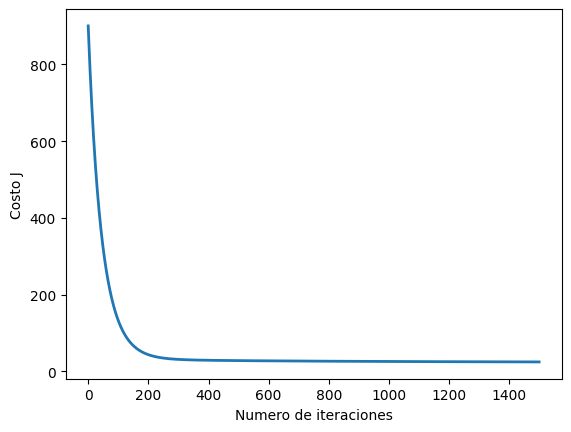

In [20]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha_pol = 0.01
num_ite_pol = 1500

# inicializa theta y ejecuta el descenso por el gradiente
theta_pol = np.zeros(X_pol_train_r.shape[1])
theta_pol, J_historico_pol = calcularDescensoGradiente(X_pol_train_r, y_pol_train, theta_pol, alpha_pol, num_ite_pol)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_historico_pol)), J_historico_pol, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print(f"los valores de theta calculados son: {theta_pol}")
print(f"con un costo de entrenamiento: {J_historico_pol[-1]}")

J_val_pol = calcularCosto(X_pol_val_r, y_pol_val, theta_pol)
print(f"costo en validación: {J_val_pol}")

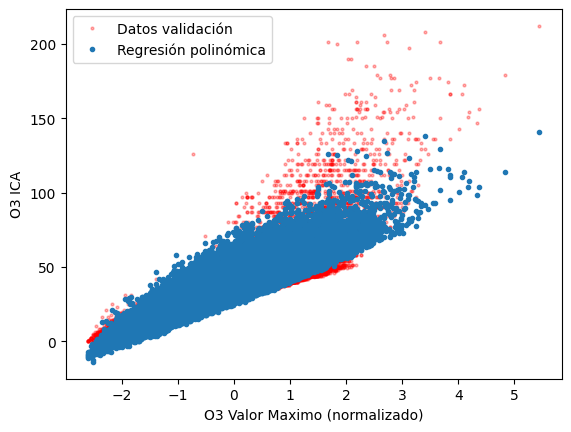

In [21]:
graficarDatos(X_pol_val_r[:, 4], y_pol_val, "O3 Valor Maximo (normalizado)", "O3 ICA")

pyplot.plot(X_pol_val_r[:, 4], np.dot(X_pol_val_r, theta_pol), '.')

pyplot.legend(['Datos validación', 'Regresión polinómica'])

In [22]:
# 120 predicciones del modelo polinómico (>= 100 requeridas)
print('{:>10s}{:>15s}{:>15s}'.format('Ejemplo', 'Real (O3 ICA)', 'Prediccion'))
print('-' * 40)
for i in range(120):
    x_pred_pol = X_pol_val_r[i]
    y_pred_pol = np.dot(x_pred_pol, theta_pol)
    print('{:>10d}{:>15.2f}{:>15.2f}'.format(i + 1, y_pol_val[i], y_pred_pol))

   Ejemplo  Real (O3 ICA)     Prediccion
----------------------------------------
         1          35.00          37.40
         2          40.00          43.07
         3          42.00          45.47
         4          51.00          58.82
         5          40.00          43.01
         6          39.00          41.05
         7          28.00          27.43
         8          30.00          29.76
         9          35.00          36.03
        10          13.00           5.44
        11          28.00          34.67
        12          34.00          36.33
        13          35.00          39.69
        14          18.00          10.79
        15          48.00          56.00
        16          27.00          24.51
        17          30.00          29.99
        18          40.00          43.29
        19          48.00          56.13
        20          50.00          56.21
        21          42.00          46.18
        22          58.00          60.64
        23      

## 8. Modelo 3 — Ecuación Normal

Calcula los parámetros $\theta$ de forma directa sin iteraciones ni tasa de aprendizaje.

$$\theta = \left( X^T X\right)^{-1} X^T \vec{y}$$

**Ventaja:** solución exacta en un solo cálculo.  
**Desventaja:** lenta con datasets muy grandes (requiere invertir una matriz).  
**Importante:** trabaja con los datos originales **sin normalizar**. Se recarga el dataset.

In [23]:
# Cargar datos sin normalizar para la ecuación normal
data_en = np.genfromtxt(
    'contaminacion_2000_2021.csv',
    delimiter=';',
    skip_header=1,
    usecols=(1, 2, 3, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 11),
    encoding='utf-8',
    invalid_raise=False
)
data_en = data_en[~np.isnan(data_en).any(axis=1)]

X_en = data_en[:, :18]
y_en = data_en[:, 18]
m_en = y_en.size

# División entrenamiento/validación
np.random.seed(42)
indices_en = np.random.permutation(m_en)
m_val_en = int(m_en * 0.2)
X_en_train = X_en[indices_en[m_val_en:]]
y_en_train = y_en[indices_en[m_val_en:]]
X_en_val   = X_en[indices_en[:m_val_en]]
y_en_val   = y_en[indices_en[:m_val_en]]

# Agregar columna de unos (sin normalizar)
X_en_train_r = np.concatenate([np.ones((X_en_train.shape[0], 1)), X_en_train], axis=1)
X_en_val_r   = np.concatenate([np.ones((X_en_val.shape[0],   1)), X_en_val],   axis=1)

print(m_en)

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_4796\1061113604.py:2: ConversionWarning: Some errors were detected !
    Line #7056 (got 5 columns instead of 19)
    Line #7057 (got 5 columns instead of 19)
    Line #7058 (got 5 columns instead of 19)
    Line #7059 (got 5 columns instead of 19)
    Line #7060 (got 5 columns instead of 19)
    Line #7061 (got 5 columns instead of 19)
    Line #7062 (got 5 columns instead of 19)
    Line #7063 (got 5 columns instead of 19)
    Line #7064 (got 5 columns instead of 19)
    Line #7065 (got 5 columns instead of 19)
    Line #7066 (got 5 columns instead of 19)
    Line #7067 (got 5 columns instead of 19)
    Line #7068 (got 5 columns instead of 19)
    Line #7069 (got 5 columns instead of 19)
    Line #7070 (got 5 columns instead of 19)
    Line #7071 (got 5 columns instead of 19)
    Line #7072 (got 5 columns instead of 19)
    Line #7073 (got 5 columns instead of 19)
    Line #7074 (got 5 columns instead of 19)
    Line #7075 (got 5 columns i

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_4796\1061113604.py:2: ConversionWarning: Some errors were detected !
    Line #7056 (got 5 columns instead of 19)
    Line #7057 (got 5 columns instead of 19)
    Line #7058 (got 5 columns instead of 19)
    Line #7059 (got 5 columns instead of 19)
    Line #7060 (got 5 columns instead of 19)
    Line #7061 (got 5 columns instead of 19)
    Line #7062 (got 5 columns instead of 19)
    Line #7063 (got 5 columns instead of 19)
    Line #7064 (got 5 columns instead of 19)
    Line #7065 (got 5 columns instead of 19)
    Line #7066 (got 5 columns instead of 19)
    Line #7067 (got 5 columns instead of 19)
    Line #7068 (got 5 columns instead of 19)
    Line #7069 (got 5 columns instead of 19)
    Line #7070 (got 5 columns instead of 19)
    Line #7071 (got 5 columns instead of 19)
    Line #7072 (got 5 columns instead of 19)
    Line #7073 (got 5 columns instead of 19)
    Line #7074 (got 5 columns instead of 19)
    Line #7075 (got 5 columns i

116363


In [24]:
def calcularThetaEcuacionNormal(X, y):
    theta = np.zeros(X.shape[1])
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

In [25]:
# Calcula los parametros con la ecuación de la normal
theta_en = calcularThetaEcuacionNormal(X_en_train_r, y_en_train)

# Muestra los resultados obtenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta_en)))

# Costo en entrenamiento y validación
J_en_train = calcularCosto(X_en_train_r, y_en_train, theta_en)
J_en_val   = calcularCosto(X_en_val_r,   y_en_val,   theta_en)
print(f'Costo entrenamiento: {J_en_train}')
print(f'Costo validación:    {J_en_val}')

Theta calculado a partir de la ecuación de la normal: [-6.95245551e+01  2.69996758e-02  2.01639900e-01 -2.68068140e-03
 -2.53594405e+02  1.51404604e+03  1.07909132e-01  2.92199706e-02
 -4.95883958e+00 -1.14140760e-02  4.92081046e-01  2.79218136e-03
 -1.71320036e-01  9.30020618e-03  1.90124392e-01 -2.19722802e-04
 -8.12668622e-02 -5.45724854e-02  8.99017349e-02]
Costo entrenamiento: 23.593773384863013
Costo validación:    23.723397034696223


In [26]:
# 120 predicciones con la ecuación normal (>= 100 requeridas)
print('{:>10s}{:>15s}{:>15s}'.format('Ejemplo', 'Real (O3 ICA)', 'Prediccion'))
print('-' * 40)
for i in range(120):
    X_array = X_en_val_r[i]
    y_pred_en = np.dot(X_array, theta_en)
    print('{:>10d}{:>15.2f}{:>15.2f}'.format(i + 1, y_en_val[i], y_pred_en))

   Ejemplo  Real (O3 ICA)     Prediccion
----------------------------------------
         1          35.00          37.80
         2          40.00          42.57
         3          42.00          44.61
         4          51.00          60.45
         5          40.00          40.85
         6          39.00          38.94
         7          28.00          27.78
         8          30.00          29.40
         9          35.00          38.47
        10          13.00           5.68
        11          28.00          34.68
        12          34.00          35.56
        13          35.00          37.56
        14          18.00          10.76
        15          48.00          55.45
        16          27.00          23.31
        17          30.00          29.12
        18          40.00          41.97
        19          48.00          56.49
        20          50.00          56.56
        21          42.00          45.14
        22          58.00          59.24
        23      